In [1]:
from datascience import *
import numpy as np
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [2]:
# Standardizing data

def standard_units(x):
    return (x - np.mean(x))/np.std(x)

In [27]:
# Functions needed to create classifications based on the distance to similar data. 

def distance(point1, point2):
    """The distance between two arrays of numbers."""
    return np.sqrt(np.sum((point1 - point2)**2))

def all_distances(training, point):
    """The distance between p (an array of numbers) and the numbers in row i of attribute_table."""
    attributes = training.drop('Class')
    def distance_from_point(row):
        return distance(point, np.array(row))
    return attributes.apply(distance_from_point)

def table_with_distances(training, point):
    """A copy of the training table with the distance from each row to array p."""
    return training.with_column('Distance', all_distances(training, point))

def closest(training, point, k):
    """A table containing the k closest rows in the training table to array p."""
    with_dists = table_with_distances(training, point)
    sorted_by_distance = with_dists.sort('Distance')
    topk = sorted_by_distance.take(np.arange(k))
    return topk

def majority(topkclasses):
    """1 if the majority of the "Class" column is 1s, and 0 otherwise."""
    ones = topkclasses.where('Class', are.equal_to(1)).num_rows
    zeros = topkclasses.where('Class', are.equal_to(0)).num_rows
    if ones > zeros:
        return 1
    else:
        return 0

def classify(training, p, k):
    """Classify an example with attributes p using k-nearest neighbor classification with the given training table."""
    closestk = closest(training, p, k)
    topkclasses = closestk.select('Class')
    return majority(topkclasses)

def show_closest(point):
    """point = array([x,y]) 
    gives the coordinates of a new point
    shown in red"""
    
    HemoGl = ckd_color.drop('White Blood Cell Count', 'Color')
    t = closest(HemoGl, point, 1)
    x_closest = t.row(0).item(1)
    y_closest = t.row(0).item(2)
    ckd_color.scatter('Hemoglobin', 'Glucose', group='Color')
    plt.scatter(point.item(0), point.item(1), color='red', s=30)
    plt.plot(make_array(point.item(0), x_closest), make_array(point.item(1), y_closest), color='k', lw=2);

In [33]:
# Functions to plot data in a particular way. 

def plot_all_points(test_grid):
    test_grid.scatter('Hemoglobin', 'Glucose', color='red', alpha=0.4, s=30)

    plt.scatter(ckd_color.column('Hemoglobin'), ckd_color.column('Glucose'), c=ckd_color.column('Color'), edgecolor='k')

    plt.xlim(-2, 2)
    plt.ylim(-2, 2);
    
def classify_grid(training, test, k):
    c = make_array()
    for i in range(test.num_rows):
        # Run the classifier on the ith patient in the test set
        c = np.append(c, classify(training, make_array(test.row(i)), k))   
    return c

def plot_all_points_classified(test_grid):
    c = classify_grid(ckd_color.drop('White Blood Cell Count', 'Color'), test_grid, 1)
    test_grid = test_grid.with_column('Class', c).join('Class', color_table)
    test_grid.scatter('Hemoglobin', 'Glucose', group='Color', alpha=0.4, s=30)

    plt.scatter(ckd_color.column('Hemoglobin'), ckd_color.column('Glucose'), c=ckd_color.column('Color'), edgecolor='k')

    plt.xlim(-2, 2)
    plt.ylim(-2, 2);

# Lecture 35 Classification

### Making Predictions
Based on incomplete information.

One way of making predictions: </br>
To predict an outcome for an individual, find others who are like that individual and whose outcomes you know. 
Use those outcomes as the basis of your prediction.

### Two Types of Prediction
    
* **Regression = Numeric**
* **Classification = Categorical**


## Classification Examples

Predicting Categorical Data. (non numeric)

### Classifying Patients ###

Chronic Kidney Disease (CKD) Predictions

* Class of 1: Patient has CKD
* Class of 0: Patient does not have CKD

Load in the data (patient records from a particular hospital) and desribe the table: 


In [5]:
# We know the class which ultimately is what we want to predict. 
# Use this data as a model to make predictions about someone new. 

ckd = Table.read_table('ckd.csv').relabeled('Blood Glucose Random', 'Glucose')
ckd.show(3)

Age,Blood Pressure,Specific Gravity,Albumin,Sugar,Red Blood Cells,Pus Cell,Pus Cell clumps,Bacteria,Glucose,Blood Urea,Serum Creatinine,Sodium,Potassium,Hemoglobin,Packed Cell Volume,White Blood Cell Count,Red Blood Cell Count,Hypertension,Diabetes Mellitus,Coronary Artery Disease,Appetite,Pedal Edema,Anemia,Class
48,70,1.005,4,0,normal,abnormal,present,notpresent,117,56,3.8,111,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,1
53,90,1.02,2,0,abnormal,abnormal,present,notpresent,70,107,7.2,114,3.7,9.5,29,12100,3.7,yes,yes,no,poor,no,yes,1
63,70,1.01,3,0,abnormal,abnormal,present,notpresent,380,60,2.7,131,4.2,10.8,32,4500,3.8,yes,yes,no,poor,yes,no,1


In [6]:
# COMPLETE: Generate a small table that shows have many patients have CKD and how many don't.
# Do not reassign. 

ckd.group('Class')

Class,count
0,115
1,43


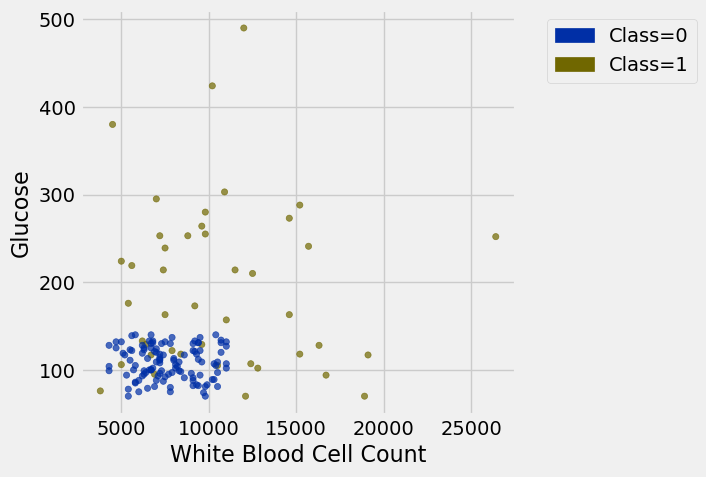

In [7]:
# COMPLETE: Generate a scatter comparing the White Blood Cell Count and Glucose grouped by Class.

ckd.scatter('White Blood Cell Count', 'Glucose', group='Class')

***QUESTION: What are some observations you can make about this comparison?***

***QUESTION: Could you predict if a new person has CKD? How would you do that?***


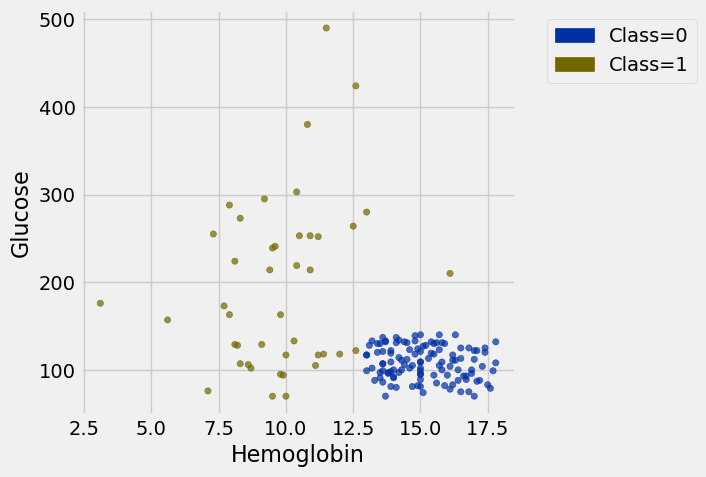

In [8]:
# COMPLETE: Generate a scatter comparing the Hemoglobin and Glucose grouped by Class.

ckd.scatter('Hemoglobin', 'Glucose', group='Class')

***QUESTION: What are some observations you can make about this comparison?***

***QUESTION: Could you predict if a new person has CKD? How would you do that?***


### Creating a Classifier

We want to be able to predict the class of someone without having to plot & eye ball this graph every time. One way to do this is to put some thresholds into code.

***QUESTION: Looking at the above scatters, what range values appear to be normal for Hemoglobin, White Blood Cells, and Glucose?***
                                                                                  

In [9]:
# What is this code doing?

max_glucose_for_0 = ckd.where('Class',are.equal_to(0)).column('Glucose').max()
min_hemoglobin_for_0 = ckd.where('Class',are.equal_to(0)).column('Hemoglobin').min()
min_hemoglobin_for_0, max_glucose_for_0


(13.0, 140)

***QUESTION: How would you define the values that are generated by this code?***



***QUESTION: Are they close to the range you thought was normal?***



In [10]:
# COMPLETE: Create a function to classify CKD based on the values of hemoglobin and glucose found above. 

def classify_manually(hemoglobin, glucose):
    if hemoglobin < min_hemoglobin_for_0 or glucose > max_glucose_for_0:
        return 1
    else:
        return 0


In [11]:
# COMPLETE: Let's try our classifier! Test the function for someone who has 100 glucose rating and 15 hemoglobin rating.

classify_manually(15, 100)

0

In [12]:
# COMPLETE: Test the function for someone who has 15 hemoglobin rating and 300 glucose rating

classify_manually(15, 300)

1

In [13]:
# COMPLETE: Test the function for someone who has 10 hemoglobin rating and 300 glucose rating

classify_manually(10, 300)

1

***QUESTION: Using the coordinate plane for the values, what do you notice about the coordinates in the previous 3 problems?***



***QUESTION: What do you notice around the coordinates with 12.5 hemoglobin and 110 glucose rating?***


    
***QUESTION: What might happen?***



## Classifying Banknotes ##

Banknotes are paper currency.

Predict whether a banknote is fraudulant or not.

* Class of 0: Not fraudulant banknote</br>
* Class of 1: Fraudulant banknote

In [14]:
# Import banknotes data. The table shows various measures by a fraud expert 
# and the resulting classification. 

banknotes = Table.read_table('banknote.csv')
banknotes

WaveletVar,WaveletSkew,WaveletCurt,Entropy,Class
3.6216,8.6661,-2.8073,-0.44699,0
4.5459,8.1674,-2.4586,-1.4621,0
3.866,-2.6383,1.9242,0.10645,0
3.4566,9.5228,-4.0112,-3.5944,0
0.32924,-4.4552,4.5718,-0.9888,0
4.3684,9.6718,-3.9606,-3.1625,0
3.5912,3.0129,0.72888,0.56421,0
2.0922,-6.81,8.4636,-0.60216,0
3.2032,5.7588,-0.75345,-0.61251,0
1.5356,9.1772,-2.2718,-0.73535,0


In [15]:
# COMPLETE: Generate a small table that shows have many banknotes are fraudulant and how many are not.
# Do not reassign. 

banknotes.group('Class')

Class,count
0,762
1,610


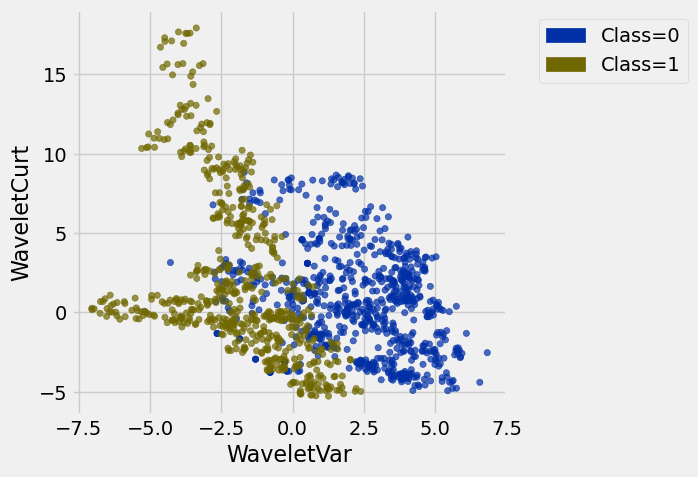

In [17]:
# COMPLETE: Generate a scatter comparing the WaveletVar and WaveletCurt grouped by Class.

banknotes.scatter('WaveletVar', 'WaveletCurt', group='Class')

***QUESTION: What are some observations you can make about this comparison?***



***QUESTION: Could you predict if a new banknote is fraudulant? How would you do that?***



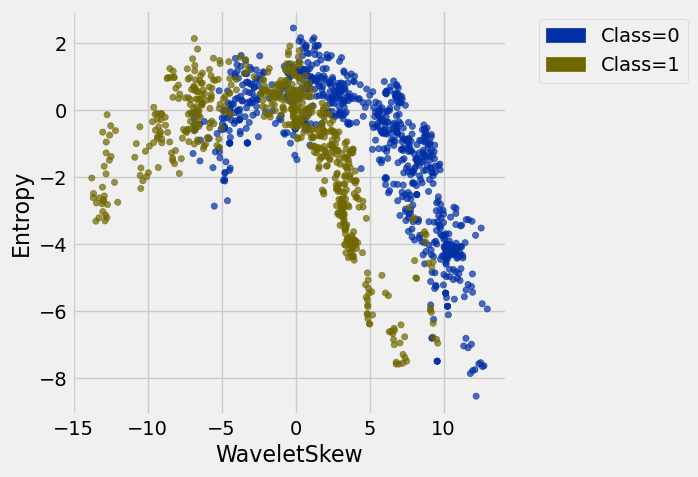

In [18]:
# COMPELTE: Generate a scatter comparing the WaveletSkew and Entropy grouped by Class.

banknotes.scatter('WaveletSkew', 'Entropy', group='Class')

***QUESTION: What are some observations you can make about this comparison?***



***QUESTION: Could you predict if a new banknote is fraudulant? How would you do that?***



### Using More Dimensions to View the Data

Some data in two dimensions leaves out interesting information. 

Increasing the dimensions may reveal additional information that helps with classification. 

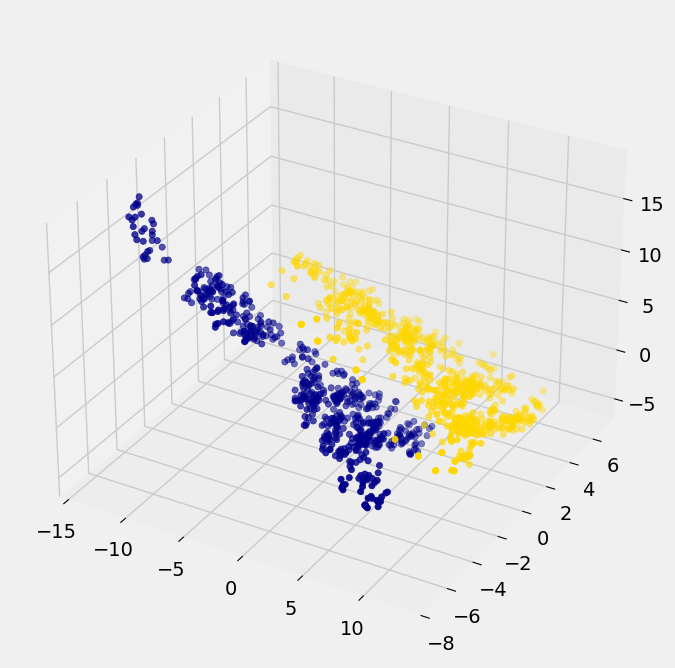

In [19]:
# Produces a 3-Dimensional graph.
# Identify them as x, y, z.

'''fig = plt.figure(figsize=(8,8))
ax = Axes3D(fig)
ax.scatter(banknotes.column('WaveletSkew'), 
           banknotes.column('WaveletVar'), 
           banknotes.column('WaveletCurt'), 
           c=banknotes.column('Class'),
           cmap='viridis',
          s=50);
'''
color_table = Table().with_columns(
    'Class', make_array(1, 0),
    'Color', make_array('darkblue', 'gold')
)
banknotes = banknotes.join('Class', color_table)

ax = plt.figure(figsize=(8,8)).add_subplot(111, projection='3d')
ax.scatter(banknotes.column('WaveletSkew'), 
           banknotes.column('WaveletVar'), 
           banknotes.column('WaveletCurt'), 
           c=banknotes.column('Color'));

***QUESTION: How does this visualization help classify fraudulant banknotes?***

***QUESTION: What variables are being used for each dimension?***

* x = ?
* y = ?
* z = ?

***QUESTION: Can you visually identify border values?***



## Nearest Neighbor Classifer

Creating a model to classify information based on the "nearest neighbors" in the data. 

* Split the sample data into a Training Set and a Test Set.
* Use the traning set to train the classifier. These are the neighbors.
* Use the test set to make sure the classifier is properly assigning the class based on known information.

This avoids bias in the classifier. 

In [20]:
# Convert CKD features into standard units
ckd = Table().with_columns(
    'Hemoglobin', standard_units(ckd.column('Hemoglobin')),
    'Glucose', standard_units(ckd.column('Glucose')),
    'White Blood Cell Count', standard_units(ckd.column('White Blood Cell Count')),
    'Class', ckd.column('Class')
)

In [24]:
# Recall Class of 0: No CKD, Class of 1: CKD

color_table = Table().with_columns(
    'Class', make_array(1, 0),
    'Color', make_array('gold', 'darkblue')
)

# Create a table that a the color table information to the original table. 

ckd_color = ckd.join('Class', color_table)
ckd_color

Class,Hemoglobin,Glucose,White Blood Cell Count,Color
0,0.456884,0.133751,0.617283,darkblue
0,1.153,-0.947597,0.424788,darkblue
0,0.770138,-0.762223,0.200211,darkblue
0,0.596108,-0.190654,-0.73018,darkblue
0,-0.239236,-0.49961,-0.0564489,darkblue
0,-0.0304002,-0.159758,0.232293,darkblue
0,0.282854,-0.00527964,0.71353,darkblue
0,0.108824,-0.623193,0.200211,darkblue
0,0.0740178,-0.515058,-0.0243664,darkblue
0,0.83975,-0.422371,-1.33975,darkblue


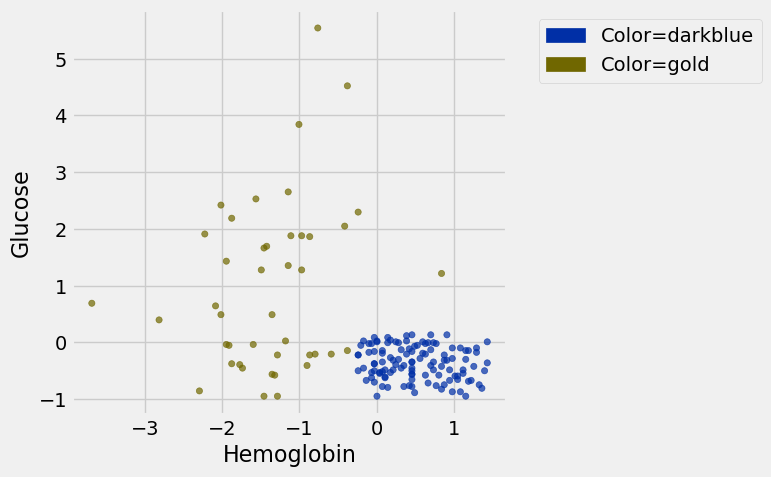

In [25]:
# COMPLETE: Generate a scatter that compares Hemoglobin and Glucose grouped by color. 

ckd_color.scatter('Hemoglobin', 'Glucose', group='Color')

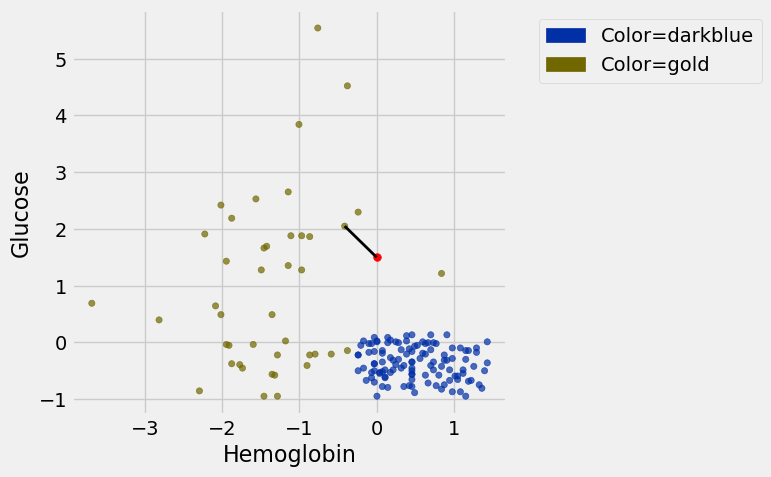

In [28]:
# New Patient 
# In this example, Alice's Hemoglobin is 0 and her Glucose is 1.5.

alice = make_array(0, 1.5)
show_closest(alice)

## Decision Boundary

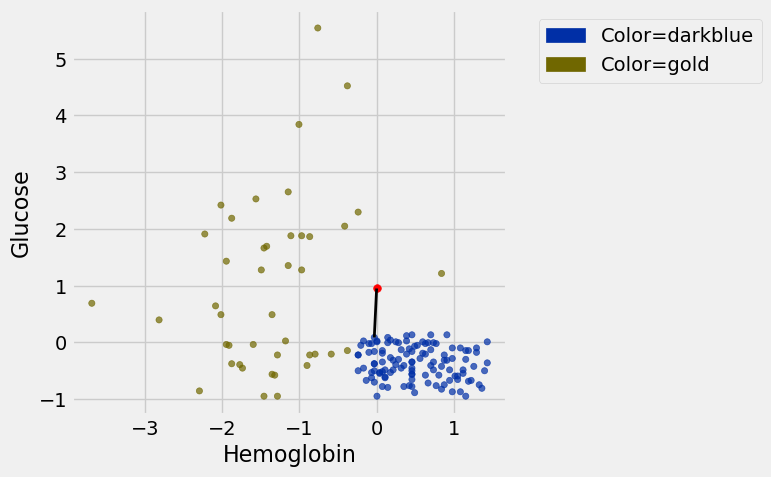

In [29]:
# New Patient 
# In this example, Alice's Hemoglobin is 0 and her Glucose is 0.95.

alice = make_array(0, 0.95)
show_closest(alice)

In [30]:
# Create a grid of all points
x_array = make_array()
y_array = make_array()
for x in np.arange(-2, 2.1, 0.1):
    for y in np.arange(-2, 2.1, 0.1):
        x_array = np.append(x_array, x)
        y_array = np.append(y_array, y)

test_grid = Table().with_columns(
    'Hemoglobin', x_array,
    'Glucose', y_array
)

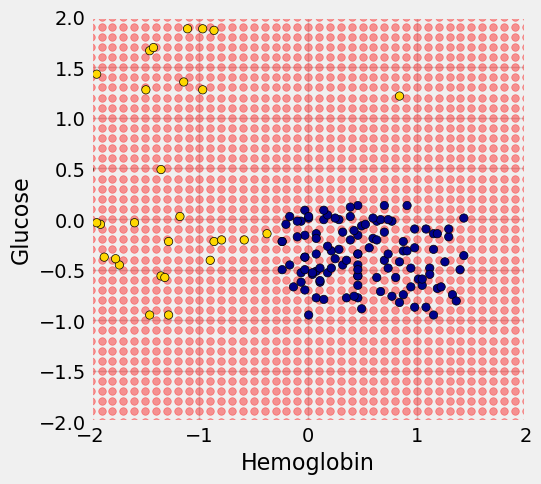

In [34]:
# Show all the points of the plane before classification.

plot_all_points(test_grid)

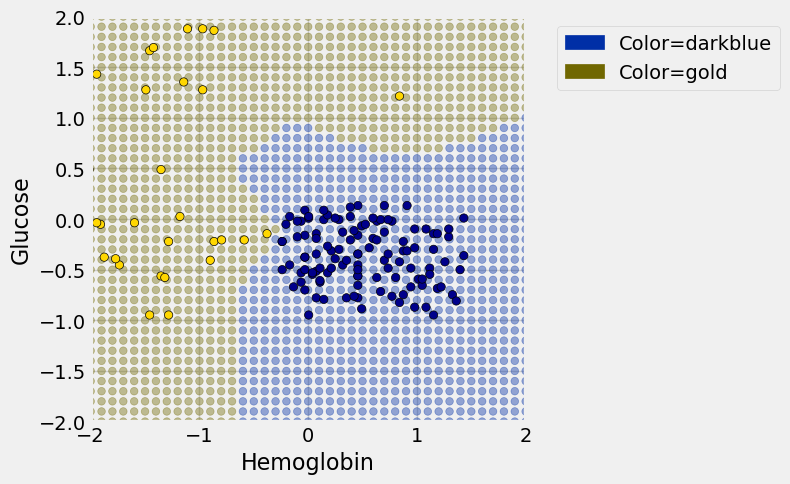

In [35]:
# Show all points on the plane classified. 

plot_all_points_classified(test_grid)

This is a simplified classifier. 

***QUESTION: Are you able to classify a new patient based on the Hemoglobin and Glucose using this grid? Why or Why not?***

